# Import Library

In [55]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, DotProduct
from sklearn.svm import SVR
import joblib
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import RandomizedSearchCV


# Import Data

In [2]:
calories_data = pd.read_csv('calories.csv')
calories_data.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [3]:
exercise_data = pd.read_csv('exercise.csv')
exercise_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


# Exploratory Data Analysis & Data Preprocessing

In [4]:
calories_data.info()
exercise_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   User_ID   15000 non-null  int64  
 1   Calories  15000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 234.5 KB
<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  str    
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
dtypes: float64(5), int64(2), str(1)
memory usage: 1011.0 KB


In [5]:
corr_calories = calories_data.corr(numeric_only=True)
plt.figure(figsize=(10,10))

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Axes: >

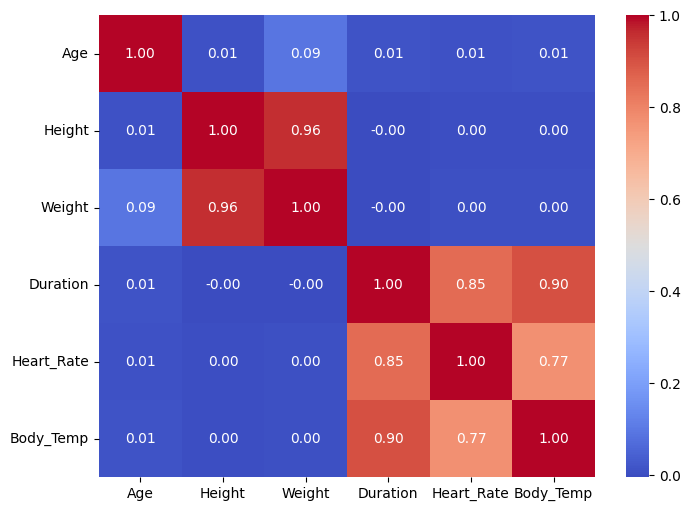

In [6]:
exercise_matrix = exercise_data.corr(numeric_only=True).drop('User_ID', axis=1).drop('User_ID', axis=0)
plt.figure(figsize=(8, 6))
sns.heatmap(exercise_matrix, annot=True, cmap='coolwarm', fmt=".2f")

In [7]:
calories_data.describe(include='all').T
calories_data.shape

(15000, 2)

In [8]:
exercise_data.describe(include='all').T
exercise_data.shape

(15000, 8)

## Merge Data

In [9]:
df = exercise_data.merge(calories_data, on='User_ID')
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [10]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
User_ID,15000.0,NaN,NaN,NaN,14977358.538467,2872851.452233,10001159.0,12474190.75,14997285.0,17449278.75,19999647.0
Gender,15000,2,female,7553,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,15000.0,NaN,NaN,NaN,42.7898,16.980264,20.0,28.0,39.0,56.0,79.0
Height,15000.0,NaN,NaN,NaN,174.465133,14.258114,123.0,164.0,175.0,185.0,222.0
Weight,15000.0,NaN,NaN,NaN,74.966867,15.035657,36.0,63.0,74.0,87.0,132.0
Duration,15000.0,NaN,NaN,NaN,15.5306,8.319203,1.0,8.0,16.0,23.0,30.0
Heart_Rate,15000.0,NaN,NaN,NaN,95.518533,9.583328,67.0,88.0,96.0,103.0,128.0
Body_Temp,15000.0,NaN,NaN,NaN,40.025453,0.77923,37.1,39.6,40.2,40.6,41.5
Calories,15000.0,NaN,NaN,NaN,89.539533,62.456978,1.0,35.0,79.0,138.0,314.0


## Correlation Matrix

<Axes: >

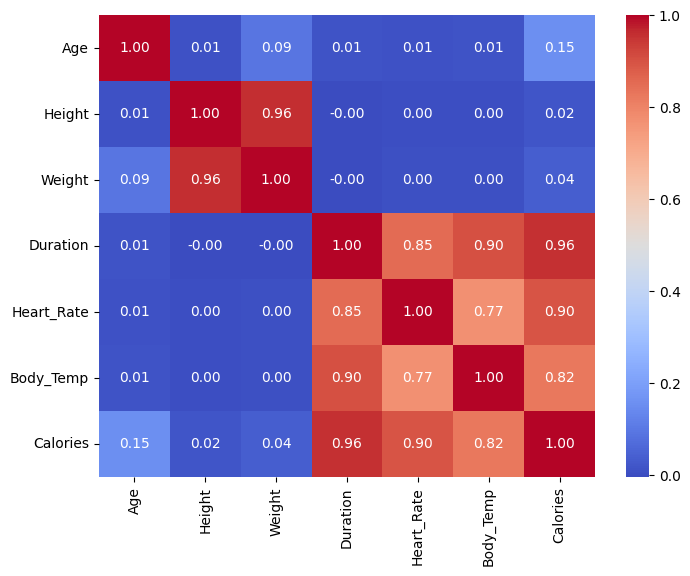

In [11]:
df_matrix = df.corr(numeric_only=True).drop('User_ID', axis=1).drop('User_ID', axis=0)
plt.figure(figsize=(8, 6))
sns.heatmap(df_matrix, annot=True, cmap='coolwarm', fmt=".2f")

## Data Cleaning

In [12]:
df.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [13]:
df.duplicated().sum()

0

## Data Visualization

### Boxplot

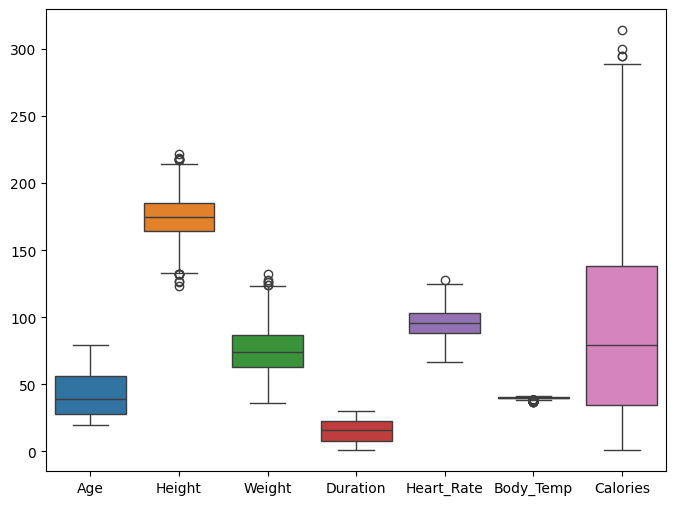

In [14]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df.drop('User_ID', axis=1))
plt.show()

### Scatter

<Axes: xlabel='Duration', ylabel='Calories'>

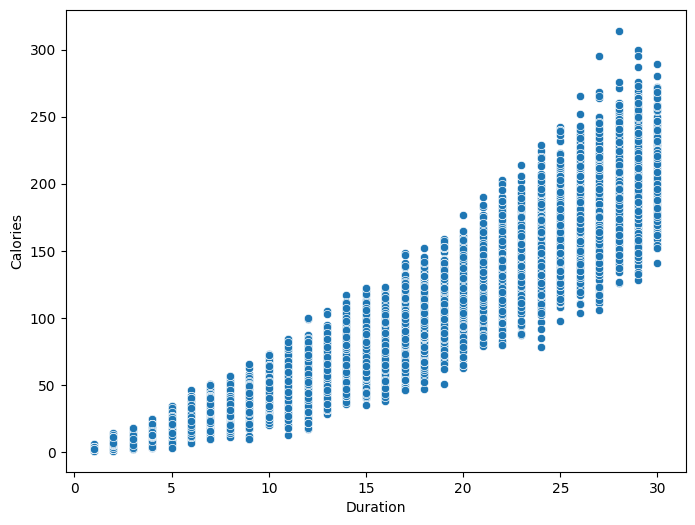

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Duration', y='Calories', data=df)

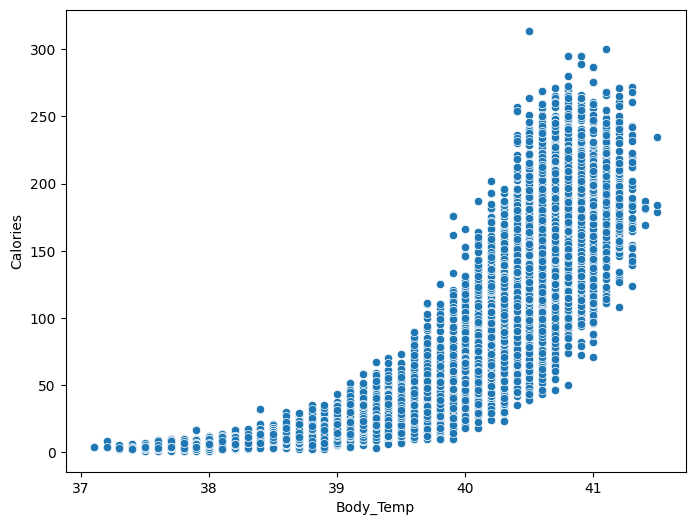

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Body_Temp', y='Calories', data=df)
plt.show()

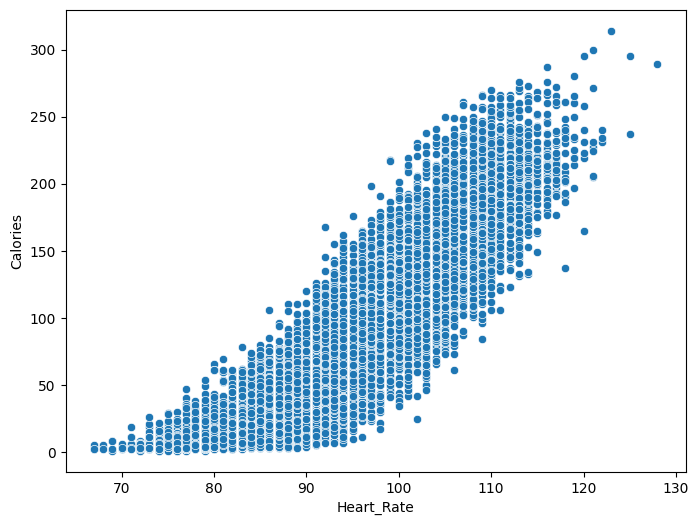

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Heart_Rate', y='Calories', data=df)
plt.show()

### Countplot

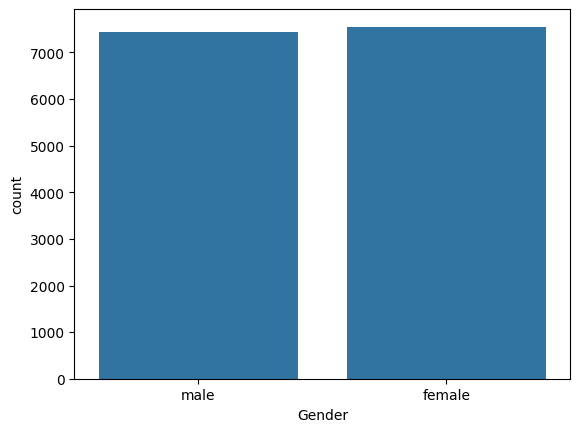

In [18]:
sns.countplot(x='Gender', data=df)
plt.show()

### Histogram

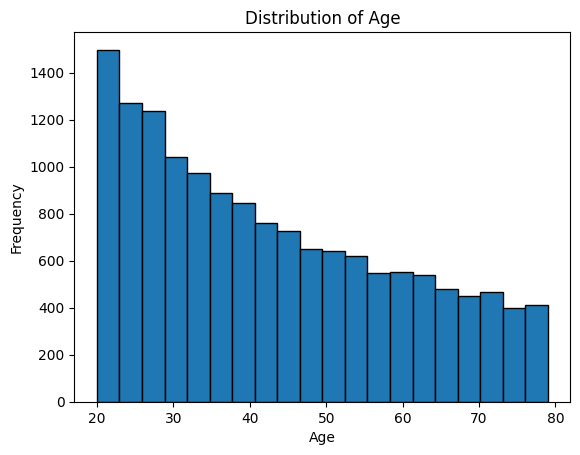

In [19]:
plt.hist(df['Age'], bins=20, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()

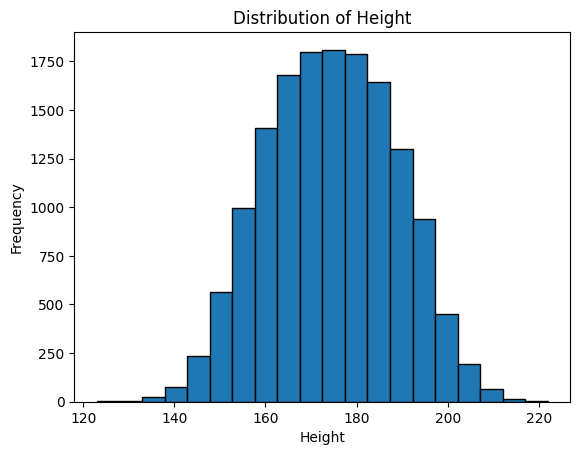

In [20]:
plt.hist(df['Height'], bins=20, edgecolor='black')
plt.xlabel('Height')
plt.ylabel('Frequency')
plt.title('Distribution of Height')
plt.show()

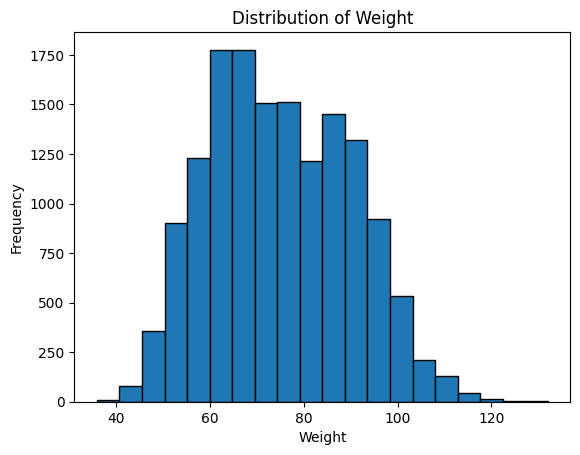

In [21]:
plt.hist(df['Weight'], bins=20, edgecolor='black')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.title('Distribution of Weight')
plt.show()

## Converting Text Data

In [22]:
df.replace({'Gender': {'male': 0, 'female': 1}}, inplace=True)

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...,...
14995,15644082,1,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,1,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,1,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,0,78,193.0,97.0,2.0,84.0,38.3,11.0


In [23]:
df['Gender'] = df['Gender'].astype(int)

# Model Training

##  Split Data

In [24]:
X = df.drop(['User_ID', 'Calories'], axis=1)
y = df['Calories']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
X_train.shape, y_train.shape

((12000, 7), (12000,))

In [27]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 12000 entries, 9839 to 7270
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      12000 non-null  int32  
 1   Age         12000 non-null  int64  
 2   Height      12000 non-null  float64
 3   Weight      12000 non-null  float64
 4   Duration    12000 non-null  float64
 5   Heart_Rate  12000 non-null  float64
 6   Body_Temp   12000 non-null  float64
dtypes: float64(5), int32(1), int64(1)
memory usage: 703.1 KB


## Fit Model

In [48]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'GPR': GaussianProcessRegressor(random_state=42),
    'SVR': SVR()
}



## Evaluation

In [49]:
results = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    results[name] = {
        'MAE': metrics.mean_absolute_error(y_test, pred),
        'MAPE': metrics.mean_absolute_percentage_error(y_test, pred),
        'RMSE': np.sqrt(metrics.mean_squared_error(y_test, pred)),
        'R2': metrics.r2_score(y_test, pred)
    }

df_results = pd.DataFrame(results).T
df_results

,MAE,MAPE,RMSE,R2
Linear Regression,8.441514,0.292178,11.488940,0.967294
Random Forest,1.715160,0.026449,2.670974,0.998232
XGBoost,1.498120,0.026703,2.137512,0.998868
GPR,87.062498,0.952308,106.881478,-1.830585
SVR,10.873748,0.276615,15.969725,0.936807


## Model Tuning

### Linear Regression

In [51]:
alpha_space = np.logspace(-4, 4, 50)
ridge_model = RidgeCV(alphas=alpha_space, cv=5)
ridge_model.fit(X_train, y_train)
print("Best Alpha:", ridge_model.alpha_)

Best Alpha: 0.0001


In [52]:
ridge_pred = ridge_model.predict(X_test)

print('MAE:', metrics.mean_absolute_error(y_test, ridge_pred))
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, ridge_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, ridge_pred)))
print('R2:', metrics.r2_score(y_test, ridge_pred))

MAE: 8.441513542717095
MAPE: 0.2921777228125155
RMSE: 11.4889401513022
R2: 0.9672937151134923


### XGBoorst

In [43]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1
)

In [44]:
grid_search.fit(X_train, y_train)
print('Best Params:', grid_search.best_params_)

Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}


In [53]:
best_model = grid_search.best_estimator_
best_pred = best_model.predict(X_test)

print('Tuned MAE:', metrics.mean_absolute_error(y_test, best_pred))
print('Tuned MAPE:', metrics.mean_absolute_percentage_error(y_test, best_pred))
print('Tuned RMSE:', np.sqrt(metrics.mean_squared_error(y_test, best_pred)))
print('Tuned R2:', metrics.r2_score(y_test, best_pred))

Tuned MAE: 1.0512349094798168
Tuned MAPE: 0.02069588731419569
Tuned RMSE: 1.4787308456257646
Tuned R2: 0.999458186844864


### SVR

In [58]:
param_dist = {
    'kernel': ['rbf'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 1],
    'gamma': ['scale', 'auto', 0.1, 1]
}

random_search = RandomizedSearchCV(
    estimator=SVR(),
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    random_state=42
)

In [59]:
random_search.fit(X_train, y_train)
print('Best Params:', random_search.best_params_)

Best Params: {'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.1, 'C': 100}


In [61]:
best_model = random_search.best_estimator_
best_pred = best_model.predict(X_test)

print('Tuned MAE:', metrics.mean_absolute_error(y_test, best_pred))
print('Tuned MAPE:', metrics.mean_absolute_percentage_error(y_test, best_pred))
print('Tuned RMSE:', np.sqrt(metrics.mean_squared_error(y_test, best_pred)))
print('Tuned R2:', metrics.r2_score(y_test, best_pred))

Tuned MAE: 2.507441831242563
Tuned MAPE: 0.04954443442846316
Tuned RMSE: 4.080136487067889
Tuned R2: 0.9958750312431646


# Import Model

In [60]:
joblib.dump(best_model, 'model.pkl')

['model.pkl']